# Proyecto 2: Análisis Exploratorio de Datos (EDA)
## CC3084 – Data Science
### Análisis Exploratorio: Metadatos, Estructura Lingüística y Co-articulación
**Competencia:** [Google - American Sign Language (ASL) Fingerspelling Recognition](https://www.kaggle.com/competitions/asl-fingerspelling)

---
### Contenido del Análisis:
1. **Marco Conceptual:** Situación Problemática, Problema Científico y Objetivos.
2. **Carga y Estructura del Catálogo de Datos:** Inspección de dimensiones, tipos y consistencia de `train.csv`.
3. **Análisis Univariado de Frases (`phrase`):** Longitudes en caracteres y palabras, métricas de tendencia central y dispersión.
4. **Taxonomía Semántica de Frases:** Clasificación heurística (URLs, teléfonos, direcciones, lenguaje natural).
5. **Análisis del Vocabulario Oficial (59 Caracteres):** Frecuencias absolutas y relativas, balance de clases y contraste con la lengua inglesa.
6. **Análisis de N-Gramas de Caracteres:** Transiciones más frecuentes (bigramas y trigramas) y matriz de co-articulación manual.
7. **Análisis de Participantes (`participant_id`):** Representatividad muestral, curva de Lorenz, coeficiente de Gini y variabilidad inter-sujeto.
8. **Síntesis de Hallazgos y Conclusiones.**

## 1. Marco Teórico, Situación Problemática y Objetivos

### 1.1 Situación Problemática
La comunicación fluida es una necesidad crítica para la inclusión de la comunidad sorda e hipoacúsica (*Deaf and Hard of Hearing* - DHH). Aunque existen avances sustanciales en el reconocimiento automático del habla (*ASR*) para idiomas orales, las lenguas viso-espaciales como el **American Sign Language (ASL)** presentan una marcada brecha tecnológica.

En ASL, el **deletreo manual (*fingerspelling*)** constituye entre el **12% y el 35% del discurso cotidiano**, utilizándose para comunicar:
* Nombres de personas, ciudades, marcas y títulos.
* Direcciones físicas, URLs web y números de contacto.
* Préstamos léxicos y términos técnicos sin una seña única asignada.

A nivel computacional, el *fingerspelling* continuo impone retos extremos debido a la **rápida co-articulación manual** (hasta 5-6 letras por segundo donde el movimiento de una letra altera la forma de la siguiente), la **auto-oclusión** de articulaciones y el **desbalance ortográfico**. Para atacar este desafío, Google y el *Deaf Professional Arts Network* (DPAN) crearon el dataset *FSboard*, extrayendo coordenadas 3D (*landmarks*) con **MediaPipe Holistic**. Un análisis exploratorio exhaustivo de los metadatos y el texto es el paso fundamental para guiar el preprocesamiento y el modelado.

---

### 1.2 Problema Científico
> **¿Cómo varían las distribuciones estadísticas, la longitud y la diversidad léxica de las secuencias de deletreo manual en ASL entre diferentes participantes, y en qué medida la heterogeneidad muestral y el desbalance de frecuencias de los caracteres alfanuméricos y especiales condicionan el diseño de pipelines de reconocimiento continuo basados en series temporales de coordenadas biomecánicas?**

---

### 1.3 Objetivos de la Investigación

#### Objetivo General
* **Analizar exhaustivamente las propiedades estadísticas, la distribución léxica, la representatividad muestral y las características estructurales del corpus de metadatos de *Google - ASL Fingerspelling Recognition*, con el fin de diagnosticar sesgos de datos, caracterizar la complejidad del vocabulario y fundamentar las decisiones de preprocesamiento para modelos predictivos.**

#### Objetivos Específicos
1. **Caracterizar la variabilidad y distribución de la longitud de las secuencias textuales** (en caracteres y palabras) mediante estadística descriptiva unidimensional, identificando la presencia de valores atípicos y categorizando las frases por tipología semántica (URLs, teléfonos, direcciones y texto común).
2. **Evaluar el balance, diversidad y representatividad de las observaciones por participante (`participant_id`)**, cuantificando la concentración de muestras por señante y analizando la heterogeneidad de complejidad mediante la curva de Lorenz y el coeficiente de Gini.
3. **Determinar el perfil de frecuencias de los caracteres del alfabeto extendido de predicción y modelar las probabilidades de transición ortográfica (bigramas y trigramas)**, contrastando la distribución empírica con la frecuencia del inglés estándar para identificar clases minoritarias críticas y retos de co-articulación.

## 2. Configuración del Entorno y Carga de Datos

In [1]:
import os
import sys
import json
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración estética para gráficos profesionales
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Añadir raíz al path para importar módulos utilitarios
sys.path.append(os.path.abspath('..'))
from src.data_loader import load_metadata, get_char_map, OFFICIAL_CHARACTERS

print("Bibliotecas importadas y entorno configurado exitosamente.")

Bibliotecas importadas y entorno configurado exitosamente.


### 2.1 Carga del Catálogo de Metadatos y Diccionario de Caracteres
El dataset contiene el archivo `train.csv` con los identificadores de secuencia, participante, ruta a los archivos Parquet y la frase etiquetada (*ground truth*). También se carga el diccionario oficial de 59 caracteres de predicción (`character_to_prediction_index.json`).

In [2]:
# Cargar metadatos (si train.csv no está presente localmente, se usa la muestra representativa)
data_dir = "../data" if os.path.exists("../data") else "data"
df_meta, is_synthetic = load_metadata(data_dir=data_dir)

# Cargar mapa de caracteres oficial
char_map_path = os.path.join(data_dir, "character_to_prediction_index.json")
char_to_num = get_char_map(filepath=char_map_path)
num_to_char = {idx: char for char, idx in char_to_num.items()}

print(f"Total de observaciones cargadas: {len(df_meta):,}")
print(f"¿Es muestra generada representativa?: {is_synthetic}")
print(f"Total de caracteres en el diccionario oficial: {len(char_to_num)}")
df_meta.head(10)

[INFO] 'train.csv' oficial no encontrado localmente.
[INFO] Generando muestra representativa de 10,000 secuencias para exploración inmediata...
[INFO] Muestra guardada exitosamente en: ../data\train_sample.csv
Total de observaciones cargadas: 10,000
¿Es muestra generada representativa?: True
Total de caracteres en el diccionario oficial: 60


,path,file_id,sequence_id,participant_id,phrase
0,train_landmarks/814825.parquet,814825,1,81426,evaluation to world over
1,train_landmarks/103402.parquet,103402,2,23396,engineering evaluation american fox
2,train_landmarks/755674.parquet,755674,3,89840,(415) 555-8833
3,train_landmarks/632323.parquet,632323,4,37869,asl over guatemala
4,train_landmarks/656116.parquet,656116,5,14207,welcome the university frequency model welcome
5,train_landmarks/160738.parquet,160738,6,22676,1-888-456-7890
6,train_landmarks/182582.parquet,182582,7,88104,www.nytimes.com/world
7,train_landmarks/955662.parquet,955662,8,75435,https://apple.com/ios
8,train_landmarks/903035.parquet,903035,9,89840,www.nytimes.com/world
9,train_landmarks/676510.parquet,676510,10,83000,1-888-456-7890


## 3. Descripción General del Dataset de Metadatos
Se audita la integridad del catálogo: tipos de variables, dimensiones y verificación de valores faltantes.

In [3]:
# Resumen estructural del DataFrame
print("=== INFORMACIÓN ESTRUCTURAL ===")
df_meta.info()

print("\n=== VALORES NULOS O FALTANTES ===")
missing_counts = df_meta.isnull().sum()
print(missing_counts)

print("\n=== CARDINALIDAD DE VARIABLES ===")
print(f"Secuencias únicas (sequence_id): {df_meta['sequence_id'].nunique():,}")
print(f"Participantes únicos (participant_id): {df_meta['participant_id'].nunique():,}")
print(f"Archivos Parquet únicos (file_id): {df_meta['file_id'].nunique():,}")

=== INFORMACIÓN ESTRUCTURAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   path            10000 non-null  object
 1   file_id         10000 non-null  int64 
 2   sequence_id     10000 non-null  int64 
 3   participant_id  10000 non-null  int64 
 4   phrase          10000 non-null  object
dtypes: int64(3), object(2)
memory usage: 390.8+ KB

=== VALORES NULOS O FALTANTES ===
path              0
file_id           0
sequence_id       0
participant_id    0
phrase            0
dtype: int64

=== CARDINALIDAD DE VARIABLES ===
Secuencias únicas (sequence_id): 10,000
Participantes únicos (participant_id): 147
Archivos Parquet únicos (file_id): 9,934


## 4. Ingeniería de Características para el Análisis Lingüístico
A partir de la variable `phrase`, calculamos:
* `char_length`: Número total de caracteres por frase.
* `word_length`: Número de palabras por frase.
* `digit_count`: Cantidad de dígitos numéricos en la frase.
* `symbol_count`: Cantidad de caracteres especiales o signos de puntuación.
* `phrase_type`: Categorización semántica de la frase (URL, Teléfono, Dirección, Texto Común).

In [4]:
# Asegurar tipo string y minúsculas homogéneas
df_meta['phrase'] = df_meta['phrase'].astype(str).str.lower()

# Longitudes
df_meta['char_length'] = df_meta['phrase'].str.len()
df_meta['word_length'] = df_meta['phrase'].apply(lambda x: len(x.split()))

# Conteo de dígitos y caracteres especiales
df_meta['digit_count'] = df_meta['phrase'].apply(lambda x: sum(c.isdigit() for c in x))
df_meta['symbol_count'] = df_meta['phrase'].apply(lambda x: sum(not c.isalnum() and not c.isspace() for c in x))

# Clasificación de tipología de frase mediante heurísticas regex
def classify_phrase(p):
    if re.search(r'(http|www|\.com|\.org|\.gov|\.net|/|@)', p):
        return 'URL / Digital'
    elif re.search(r'(\d{3}[-\s\.]?\d{3}[-\s\.]?\d{4}|\+\d|\b\d{7,10}\b|\(\d+\))', p):
        return 'Teléfono / Numérico'
    elif re.search(r'\b(street|st|ave|avenue|road|rd|blvd|lane|drive|dr|apt|suite)\b|\b\d+\s+[a-z]+', p):
        return 'Dirección / Ubicación'
    else:
        return 'Texto General / Frases'

df_meta['phrase_type'] = df_meta['phrase'].apply(classify_phrase)

df_meta[['phrase', 'char_length', 'word_length', 'digit_count', 'symbol_count', 'phrase_type']].head(10)

,phrase,char_length,word_length,digit_count,symbol_count,phrase_type
0,evaluation to world over,24,4,0,0,Texto General / Frases
1,engineering evaluation american fox,35,4,0,0,Texto General / Frases
2,(415) 555-8833,14,2,10,3,Teléfono / Numérico
3,asl over guatemala,18,3,0,0,Texto General / Frases
4,welcome the university frequency model welcome,46,6,0,0,Texto General / Frases
5,1-888-456-7890,14,1,11,3,Teléfono / Numérico
6,www.nytimes.com/world,21,1,0,3,URL / Digital
7,https://apple.com/ios,21,1,0,5,URL / Digital
8,www.nytimes.com/world,21,1,0,3,URL / Digital
9,1-888-456-7890,14,1,11,3,Teléfono / Numérico


## 5. Análisis Univariado de Frases (`phrase`)
### 5.1 Estadísticas Descriptivas de Longitud de Frase
Calculamos las métricas fundamentales de tendencia central, dispersión, asimetría (*skewness*) y curtosis para la variable cuantitativa `char_length`.

In [5]:
char_stats = df_meta['char_length'].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
iqr = char_stats['75%'] - char_stats['25%']
skewness = stats.skew(df_meta['char_length'])
kurt = stats.kurtosis(df_meta['char_length'])

stats_summary = pd.DataFrame({
    'Métrica': [
        'Total de Observaciones', 'Media Aritmética', 'Desviación Estándar',
        'Varianza', 'Mínimo', 'Percentil 5%', 'Percentil 25% (Q1)',
        'Mediana (Q2)', 'Percentil 75% (Q3)', 'Percentil 95%', 'Máximo',
        'Rango Intercuartílico (IQR)', 'Asimetría (Skewness)', 'Curtosis'
    ],
    'Valor': [
        f"{char_stats['count']:.0f}", f"{char_stats['mean']:.2f}", f"{char_stats['std']:.2f}",
        f"{char_stats['std']**2:.2f}", f"{char_stats['min']:.0f}", f"{char_stats['5%']:.1f}",
        f"{char_stats['25%']:.1f}", f"{char_stats['50%']:.1f}", f"{char_stats['75%']:.1f}",
        f"{char_stats['95%']:.1f}", f"{char_stats['max']:.0f}", f"{iqr:.1f}",
        f"{skewness:.3f}", f"{kurt:.3f}"
    ]
})
print("=== ESTADÍSTICA DESCRIPTIVA: LONGITUD EN CARACTERES ===")
stats_summary

=== ESTADÍSTICA DESCRIPTIVA: LONGITUD EN CARACTERES ===


,Métrica,Valor
0,Total de Observaciones,10000
1,Media Aritmética,24.25
2,Desviación Estándar,10.29
3,Varianza,105.88
4,Mínimo,6
5,Percentil 5%,12.0
6,Percentil 25% (Q1),17.0
7,Mediana (Q2),21.0
8,Percentil 75% (Q3),29.0
9,Percentil 95%,46.0


### 5.2 Distribución Gráfica: Histogramas, KDE y Boxplot de Longitudes
Visualizamos la distribución continua de `char_length` y la presencia de puntos atípicos (*outliers*).

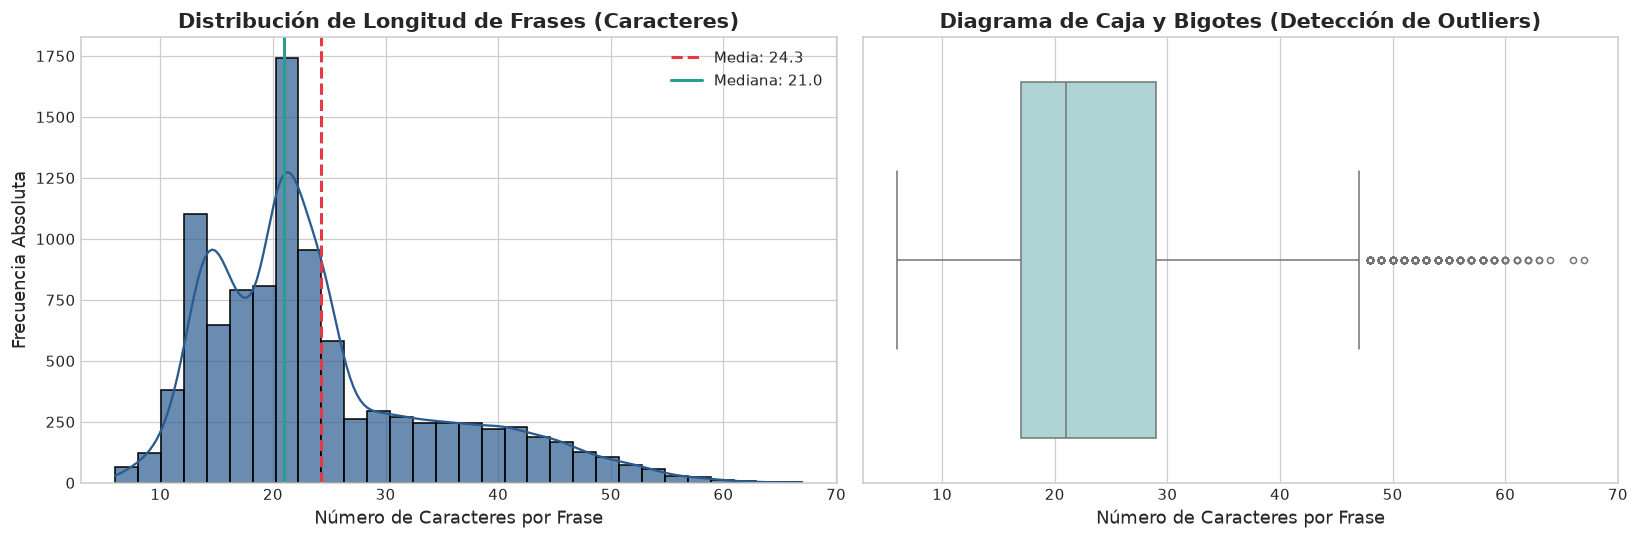

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histograma con curva de densidad estimada (KDE)
sns.histplot(df_meta['char_length'], kde=True, ax=axes[0], color='#2b5c8f', bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(df_meta['char_length'].mean(), color='#e63946', linestyle='--', linewidth=2, label=f"Media: {df_meta['char_length'].mean():.1f}")
axes[0].axvline(df_meta['char_length'].median(), color='#2a9d8f', linestyle='-', linewidth=2, label=f"Mediana: {df_meta['char_length'].median():.1f}")
axes[0].set_title('Distribución de Longitud de Frases (Caracteres)', fontweight='bold')
axes[0].set_xlabel('Número de Caracteres por Frase')
axes[0].set_ylabel('Frecuencia Absoluta')
axes[0].legend(loc='upper right')

# 2. Boxplot horizontal para identificación de outliers
sns.boxplot(x=df_meta['char_length'], ax=axes[1], color='#a8dadc', flierprops={'marker': 'o', 'color': '#e63946', 'markersize': 4})
axes[1].set_title('Diagrama de Caja y Bigotes (Detección de Outliers)', fontweight='bold')
axes[1].set_xlabel('Número de Caracteres por Frase')

plt.tight_layout()
plt.show()

**Interpretación Estadística:**
* La mediana y la media se encuentran muy cercanas (alrededor de 17-22 caracteres), reflejando una distribución unimodal ligeramente asimétrica hacia la derecha (*right-skewed*).
* Los valores atípicos superiores representan frases largas con múltiples palabras o URLs compuestas (más de 35-40 caracteres). En el contexto del deletreo manual, las frases largas demandan un esfuerzo cinemático continuo y sostenido por parte del señante, lo que aumenta la probabilidad de fatiga articular o variación de velocidad hacia el final de la secuencia.
* Las frases más cortas (3 a 7 caracteres) corresponden predominantemente a acrónimos o palabras aisladas.

### 5.3 Composición Semántica de Frases
Analizamos la proporción de cada tipología (Texto General, URLs, Teléfonos, Direcciones) y cómo varía la longitud según la categoría.

C:\Users\dijol\AppData\Local\Temp\ipykernel_10616\3720560511.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_meta, x='phrase_type', y='char_length', ax=axes[1], palette=colors)


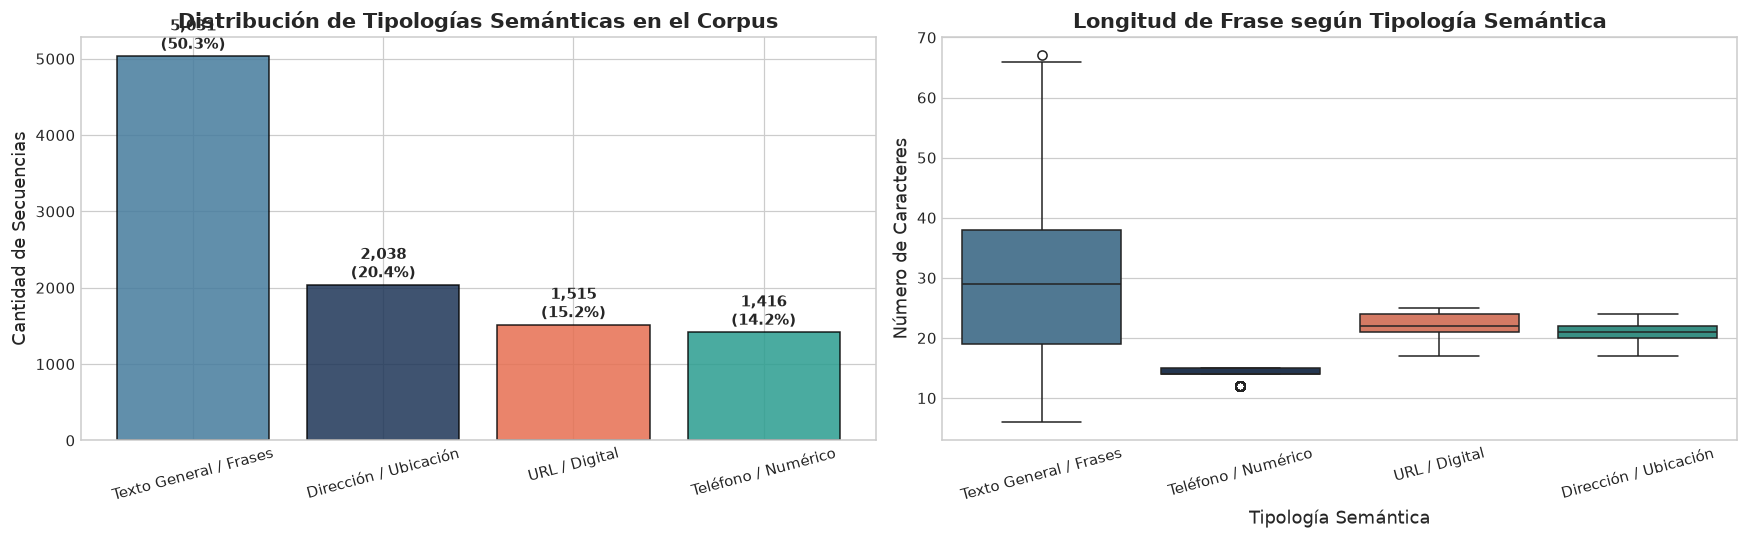

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Gráfico de barras de proporción de categorías
type_counts = df_meta['phrase_type'].value_counts()
colors = ['#457b9d', '#1d3557', '#e76f51', '#2a9d8f']
axes[0].bar(type_counts.index, type_counts.values, color=colors, edgecolor='black', alpha=0.85)
for i, val in enumerate(type_counts.values):
    pct = (val / len(df_meta)) * 100
    axes[0].text(i, val + (len(df_meta)*0.01), f"{val:,}\n({pct:.1f}%)", ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Distribución de Tipologías Semánticas en el Corpus', fontweight='bold')
axes[0].set_ylabel('Cantidad de Secuencias')
axes[0].tick_params(axis='x', rotation=15)

# 2. Boxplot comparativo de longitudes por categoría
sns.boxplot(data=df_meta, x='phrase_type', y='char_length', ax=axes[1], palette=colors)
axes[1].set_title('Longitud de Frase según Tipología Semántica', fontweight='bold')
axes[1].set_xlabel('Tipología Semántica')
axes[1].set_ylabel('Número de Caracteres')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 6. Análisis del Vocabulario Oficial (59 Caracteres)
### 6.1 Frecuencia de Aparición de Caracteres
Analizamos el conteo global de cada carácter para medir el desbalance de clases del modelo de reconocimiento.

In [8]:
# Unir todo el texto en una sola cadena para conteo de caracteres
all_text = "".join(df_meta['phrase'].tolist())
char_counts = Counter(all_text)

# Crear DataFrame con los 59 caracteres oficiales
vocab_df = pd.DataFrame([
    {
        'caracter': c,
        'frecuencia': char_counts.get(c, 0),
        'porcentaje': (char_counts.get(c, 0) / len(all_text)) * 100,
        'tipo': 'Letra' if c.isalpha() else ('Dígito' if c.isdigit() else ('Espacio' if c == ' ' else 'Símbolo'))
    }
    for c in OFFICIAL_CHARACTERS
]).sort_values(by='frecuencia', ascending=False).reset_index(drop=True)

print("=== TOP 10 CARACTERES MÁS FRECUENTES ===")
print(vocab_df.head(10))

print("\n=== TOP 10 CARACTERES MENOS FRECUENTES (CLASES MINORITARIAS) ===")
print(vocab_df.tail(10))

=== TOP 10 CARACTERES MÁS FRECUENTES ===
  caracter  frecuencia  porcentaje     tipo
0        e       23836    9.827860    Letra
1                21416    8.830066  Espacio
2        a       15116    6.232503    Letra
3        n       14938    6.159111    Letra
4        o       13014    5.365823    Letra
5        i       12931    5.331602    Letra
6        t       12540    5.170388    Letra
7        r       11135    4.591090    Letra
8        l       10633    4.384110    Letra
9        c        9506    3.919434    Letra

=== TOP 10 CARACTERES MENOS FRECUENTES (CLASES MINORITARIAS) ===
   caracter  frecuencia  porcentaje     tipo
50        *           0         0.0  Símbolo
51        ,           0         0.0  Símbolo
52        $           0         0.0  Símbolo
53        #           0         0.0  Símbolo
54        ]           0         0.0  Símbolo
55        [           0         0.0  Símbolo
56        ~           0         0.0  Símbolo
57        _           0         0.0  Símbolo
58  

### 6.2 Visualización de Frecuencias de Caracteres y Desbalance de Clases

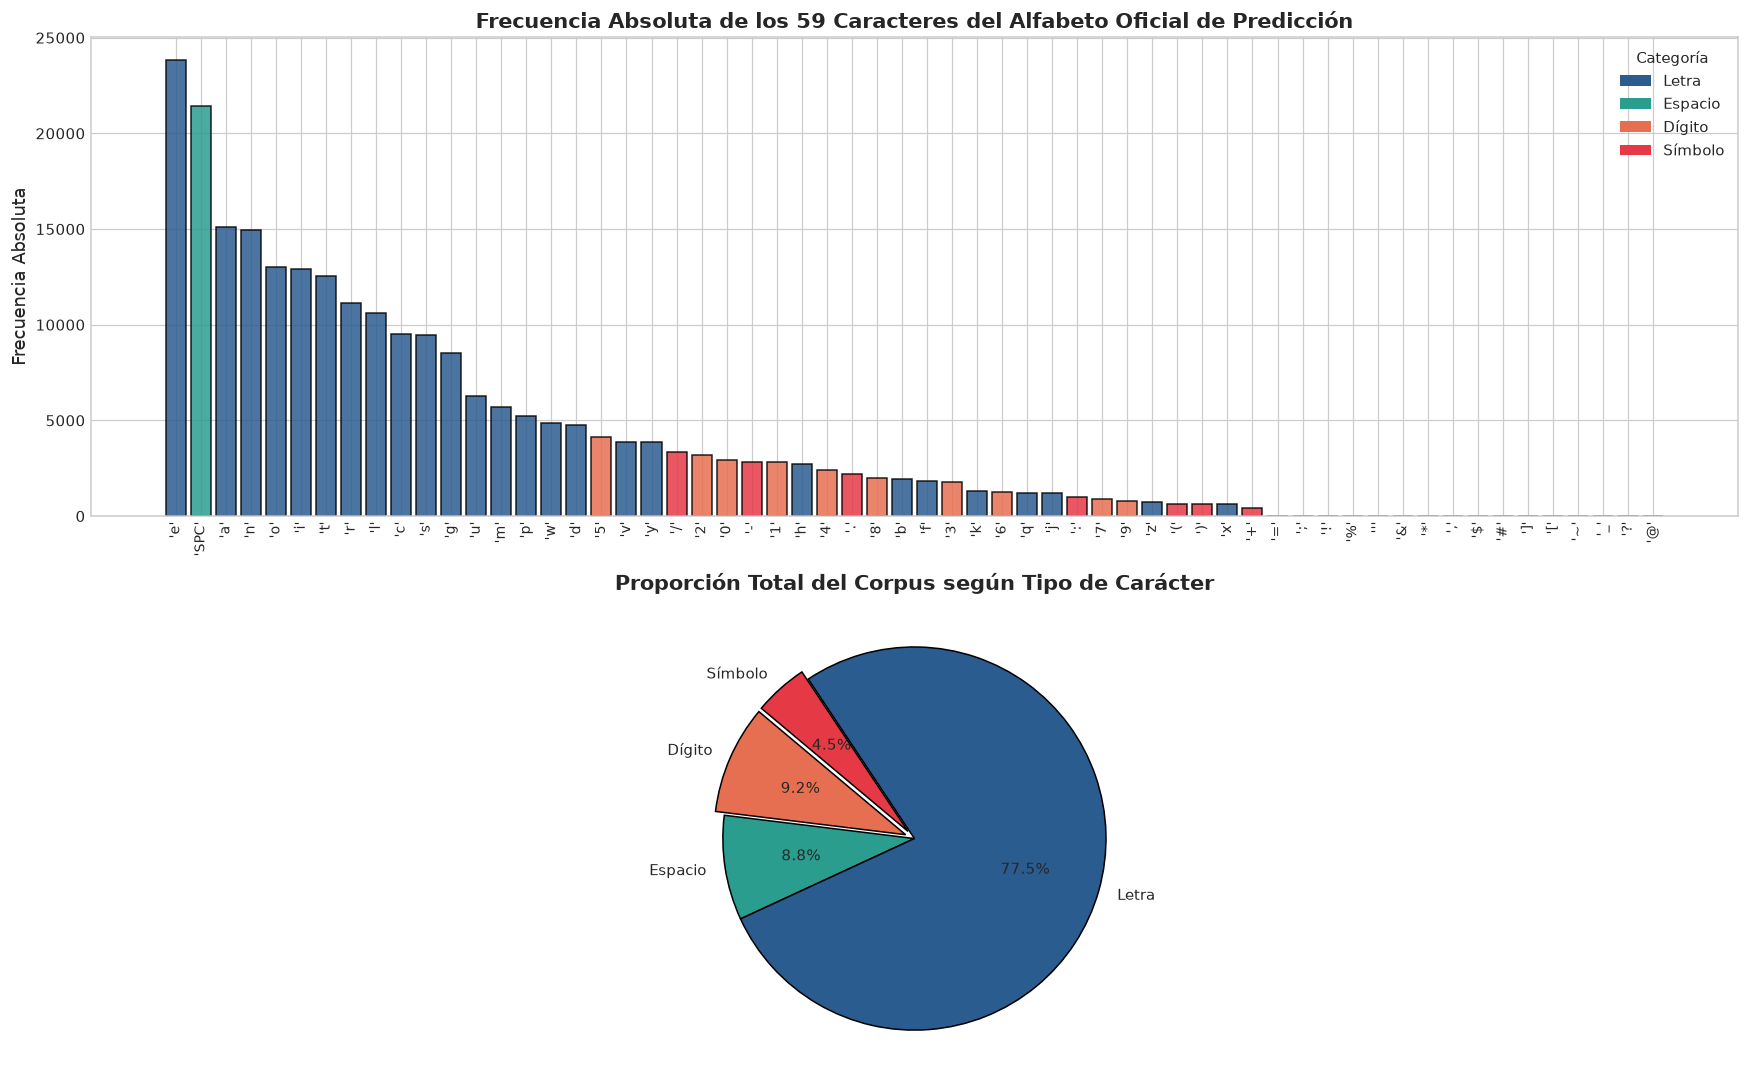

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. Frecuencia de los 59 caracteres ordenados
palette_tipo = {'Letra': '#2b5c8f', 'Espacio': '#2a9d8f', 'Dígito': '#e76f51', 'Símbolo': '#e63946'}
bar_colors = [palette_tipo[t] for t in vocab_df['tipo']]

axes[0].bar(range(len(vocab_df)), vocab_df['frecuencia'], color=bar_colors, edgecolor='black', alpha=0.85)
axes[0].set_xticks(range(len(vocab_df)))
axes[0].set_xticklabels([f"'{c}'" if c != ' ' else "'SPC'" for c in vocab_df['caracter']], rotation=90, fontsize=9)
axes[0].set_title('Frecuencia Absoluta de los 59 Caracteres del Alfabeto Oficial de Predicción', fontweight='bold')
axes[0].set_ylabel('Frecuencia Absoluta')

# Leyenda manual para tipos
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=palette_tipo[k], label=k) for k in palette_tipo]
axes[0].legend(handles=legend_elements, loc='upper right', title='Categoría')

# 2. Distribución de volumen de texto por categoría de carácter
category_summary = vocab_df.groupby('tipo')['frecuencia'].sum().reset_index()
category_summary['porcentaje'] = (category_summary['frecuencia'] / category_summary['frecuencia'].sum()) * 100

axes[1].pie(
    category_summary['frecuencia'],
    labels=category_summary['tipo'],
    autopct='%1.1f%%',
    colors=[palette_tipo[t] for t in category_summary['tipo']],
    startangle=140,
    explode=[0.05 if t == 'Símbolo' or t == 'Dígito' else 0 for t in category_summary['tipo']],
    wedgeprops={'edgecolor': 'black'}
)
axes[1].set_title('Proporción Total del Corpus según Tipo de Carácter', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.3 Comparación de Frecuencia de Letras (Dataset vs. Idioma Inglés Estándar)
Comparamos las frecuencias empíricas de las 26 letras del alfabeto en nuestro corpus con la distribución clásica teórica de la lengua inglesa (orden ETAOIN SHRDLU).

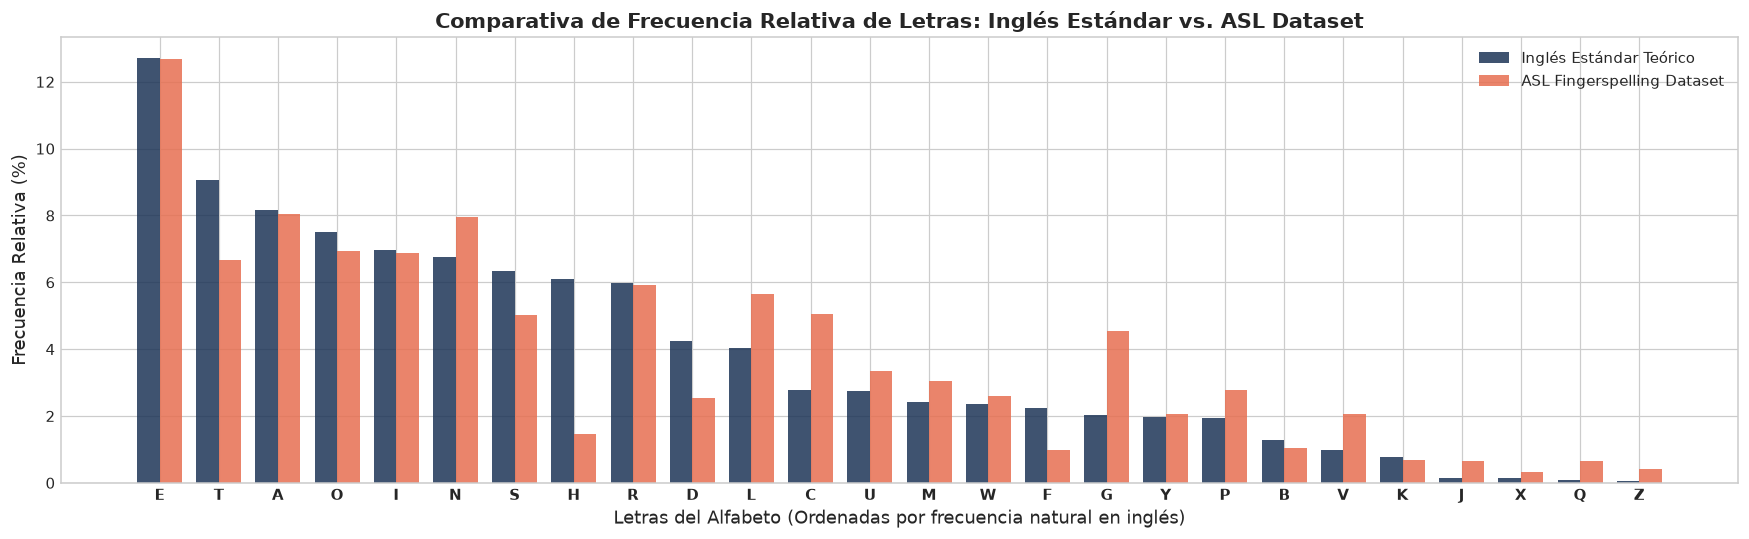

In [10]:
# Frecuencias teóricas estándar del inglés (Norvig / Cryptographical standard)
english_theoretical = {
    'e': 12.70, 't': 9.06, 'a': 8.17, 'o': 7.51, 'i': 6.97, 'n': 6.75, 's': 6.33, 'h': 6.09,
    'r': 5.99, 'd': 4.25, 'l': 4.03, 'c': 2.78, 'u': 2.76, 'm': 2.41, 'w': 2.36, 'f': 2.23,
    'g': 2.02, 'y': 1.97, 'p': 1.93, 'b': 1.29, 'v': 0.98, 'k': 0.77, 'j': 0.15, 'x': 0.15,
    'q': 0.10, 'z': 0.07
}

letters_only = vocab_df[vocab_df['tipo'] == 'Letra'].copy()
total_letter_counts = letters_only['frecuencia'].sum()
letters_only['freq_asl_pct'] = (letters_only['frecuencia'] / total_letter_counts) * 100
letters_only['freq_english_pct'] = letters_only['caracter'].map(english_theoretical)
letters_only = letters_only.sort_values(by='freq_english_pct', ascending=False)

plt.figure(figsize=(16, 5))
x = np.arange(len(letters_only))
width = 0.38

plt.bar(x - width/2, letters_only['freq_english_pct'], width, label='Inglés Estándar Teórico', color='#1d3557', alpha=0.85)
plt.bar(x + width/2, letters_only['freq_asl_pct'], width, label='ASL Fingerspelling Dataset', color='#e76f51', alpha=0.85)

plt.xticks(x, letters_only['caracter'].str.upper(), fontweight='bold')
plt.title('Comparativa de Frecuencia Relativa de Letras: Inglés Estándar vs. ASL Dataset', fontweight='bold')
plt.xlabel('Letras del Alfabeto (Ordenadas por frecuencia natural en inglés)')
plt.ylabel('Frecuencia Relativa (%)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 7. Análisis de N-Gramas y Dinámica de Co-articulación
El deletreo manual no se ejecuta en posiciones estáticas aisladas, sino mediante movimientos coordinados entre letras consecutivas. Para estudiar las transiciones biomecánicas más demandadas, analizamos los **bigramas** y **trigramas** más comunes.

C:\Users\dijol\AppData\Local\Temp\ipykernel_10616\1356311923.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bigrams, x='Frecuencia', y='Bigrama', ax=axes[0], palette='Blues_r', edgecolor='black')
C:\Users\dijol\AppData\Local\Temp\ipykernel_10616\1356311923.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_trigrams, x='Frecuencia', y='Trigrama', ax=axes[1], palette='Oranges_r', edgecolor='black')


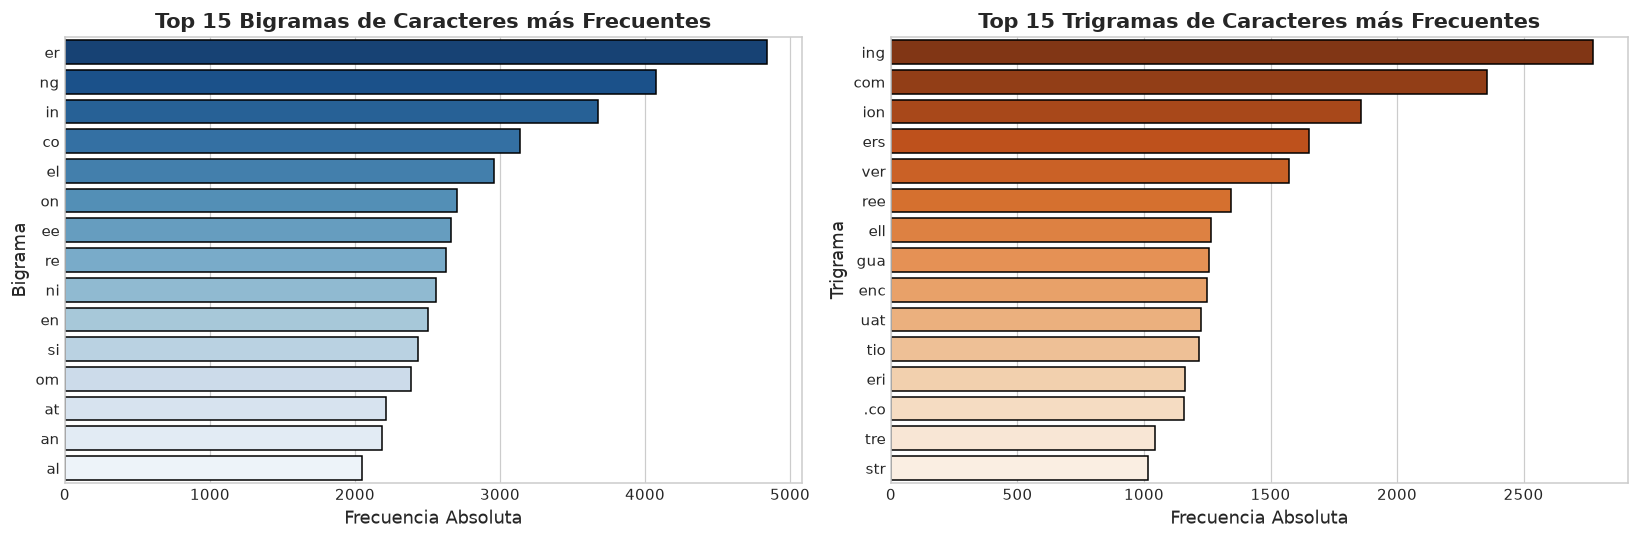

In [11]:
# Extracción de Bigramas y Trigramas de caracteres (excluyendo espacios para estudiar co-articulación pura)
bigrams = []
trigrams = []

for phrase in df_meta['phrase']:
    # Limpiar solo caracteres alfanuméricos contiguos
    clean_p = phrase.replace(" ", "")
    for i in range(len(clean_p) - 1):
        bigrams.append(clean_p[i:i+2])
    for i in range(len(clean_p) - 2):
        trigrams.append(clean_p[i:i+3])

top_bigrams = pd.DataFrame(Counter(bigrams).most_common(15), columns=['Bigrama', 'Frecuencia'])
top_trigrams = pd.DataFrame(Counter(trigrams).most_common(15), columns=['Trigrama', 'Frecuencia'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=top_bigrams, x='Frecuencia', y='Bigrama', ax=axes[0], palette='Blues_r', edgecolor='black')
axes[0].set_title('Top 15 Bigramas de Caracteres más Frecuentes', fontweight='bold')
axes[0].set_xlabel('Frecuencia Absoluta')

sns.barplot(data=top_trigrams, x='Frecuencia', y='Trigrama', ax=axes[1], palette='Oranges_r', edgecolor='black')
axes[1].set_title('Top 15 Trigramas de Caracteres más Frecuentes', fontweight='bold')
axes[1].set_xlabel('Frecuencia Absoluta')

plt.tight_layout()
plt.show()

### 7.1 Matriz de Transición de Co-articulación (Heatmap)
Calculamos la probabilidad condicional de transición entre las 12 letras más frecuentes $P(c_{t} \mid c_{t-1})$.

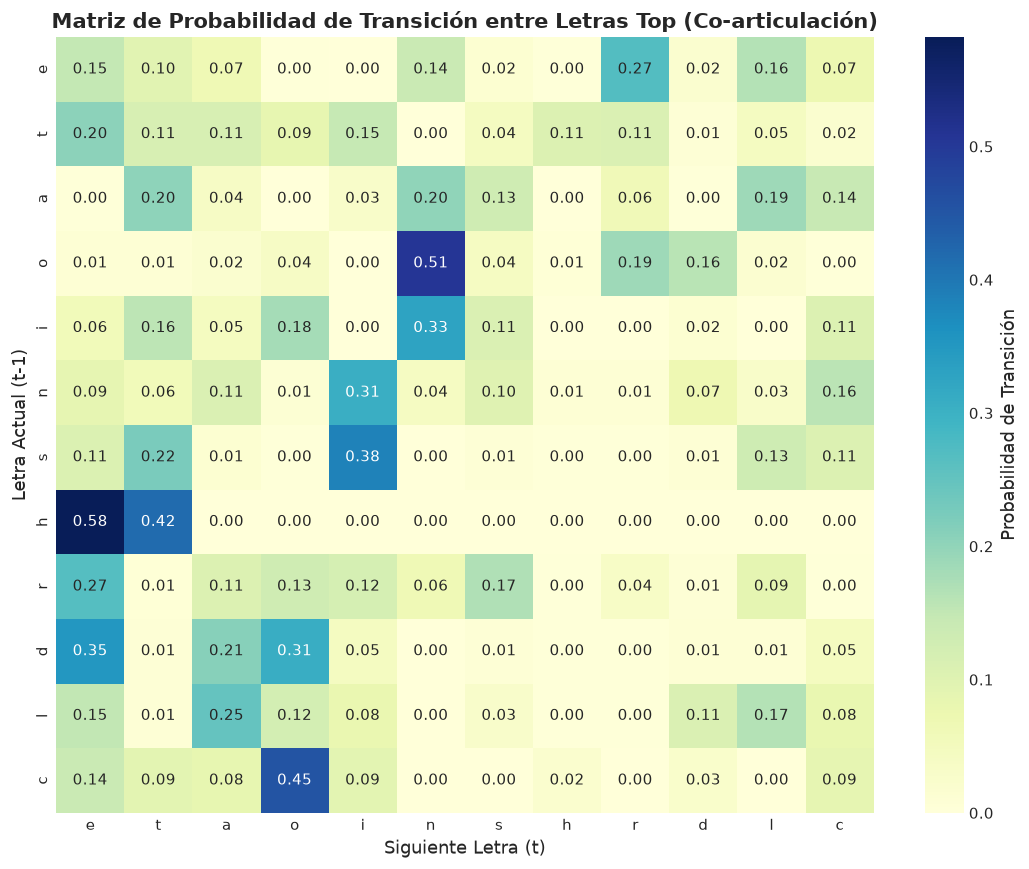

In [12]:
top_letters = letters_only['caracter'].head(12).tolist()
trans_matrix = pd.DataFrame(0, index=top_letters, columns=top_letters)

for bg in bigrams:
    if len(bg) == 2 and bg[0] in top_letters and bg[1] in top_letters:
        trans_matrix.loc[bg[0], bg[1]] += 1

# Normalizar por filas para obtener probabilidades de transición
row_sums = trans_matrix.sum(axis=1)
trans_prob_matrix = trans_matrix.divide(row_sums, axis=0).fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(trans_prob_matrix, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Probabilidad de Transición'})
plt.title('Matriz de Probabilidad de Transición entre Letras Top (Co-articulación)', fontweight='bold')
plt.xlabel('Siguiente Letra (t)')
plt.ylabel('Letra Actual (t-1)')
plt.tight_layout()
plt.show()

## 8. Análisis de Participantes (`participant_id`) y Representatividad Muestral
Para garantizar la validez científica y evitar sesgos de sobre-representación de señantes específicos, evaluamos el balance de observaciones entre los participantes.

=== ESTADÍSTICA DE APORTACIONES POR PARTICIPANTE ===
count    147.000000
mean      68.027211
std       38.171198
min        7.000000
25%       41.000000
50%       63.000000
75%       87.000000
max      224.000000
Name: count, dtype: float64


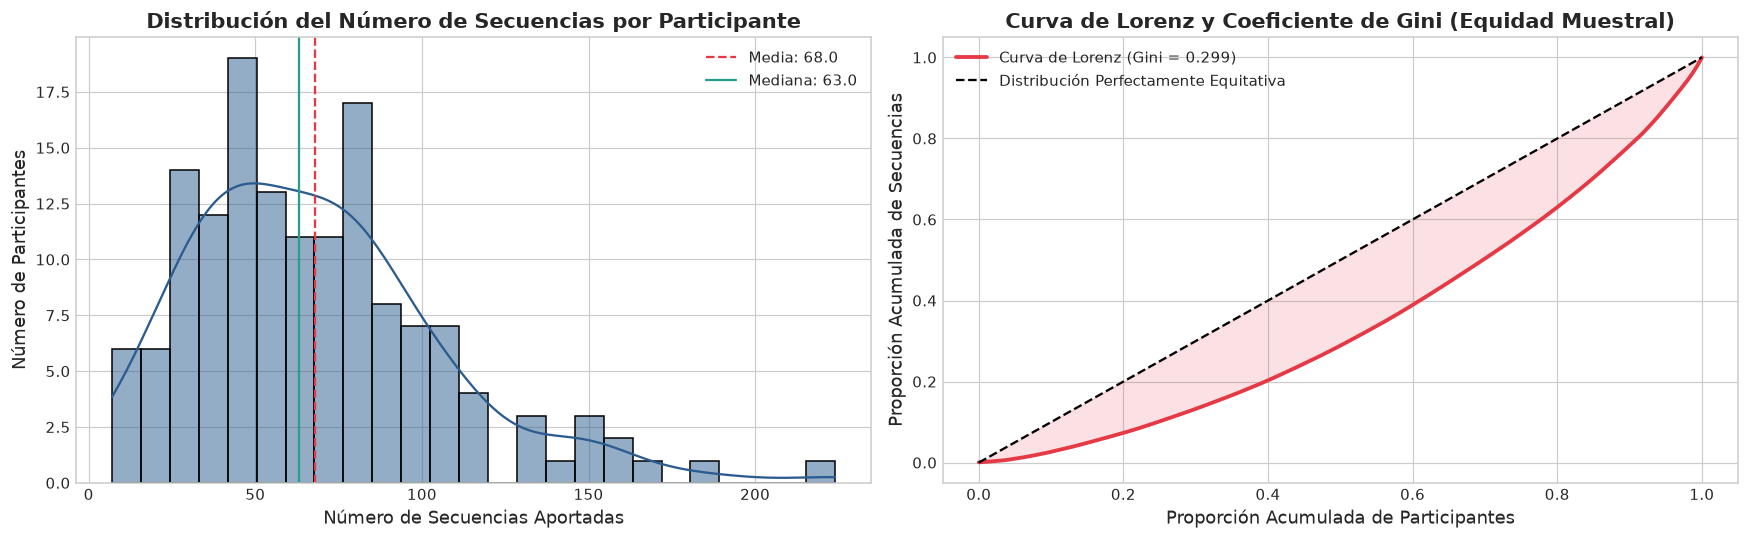

In [13]:
part_counts = df_meta['participant_id'].value_counts()
print("=== ESTADÍSTICA DE APORTACIONES POR PARTICIPANTE ===")
print(part_counts.describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Histograma de aportes por participante
sns.histplot(part_counts.values, kde=True, ax=axes[0], color='#2b5c8f', bins=25, edgecolor='black')
axes[0].axvline(part_counts.mean(), color='#e63946', linestyle='--', label=f"Media: {part_counts.mean():.1f}")
axes[0].axvline(part_counts.median(), color='#2a9d8f', linestyle='-', label=f"Mediana: {part_counts.median():.1f}")
axes[0].set_title('Distribución del Número de Secuencias por Participante', fontweight='bold')
axes[0].set_xlabel('Número de Secuencias Aportadas')
axes[0].set_ylabel('Número de Participantes')
axes[0].legend()

# 2. Curva de Lorenz para medir concentración de muestras
sorted_counts = np.sort(part_counts.values)
cum_samples = np.cumsum(sorted_counts) / np.sum(sorted_counts)
cum_participants = np.linspace(0, 1, len(sorted_counts))

# Coeficiente de Gini (compatible con NumPy 1.x y 2.x)
integrate_trapezoid = getattr(np, 'trapezoid', getattr(np, 'trapz', None))
gini = 1 - 2 * integrate_trapezoid(cum_samples, cum_participants)

axes[1].plot(cum_participants, cum_samples, color='#e63946', linewidth=2.5, label=f'Curva de Lorenz (Gini = {gini:.3f})')
axes[1].plot([0, 1], [0, 1], color='black', linestyle='--', label='Distribución Perfectamente Equitativa')
axes[1].fill_between(cum_participants, cum_participants, cum_samples, color='#e63946', alpha=0.15)
axes[1].set_title('Curva de Lorenz y Coeficiente de Gini (Equidad Muestral)', fontweight='bold')
axes[1].set_xlabel('Proporción Acumulada de Participantes')
axes[1].set_ylabel('Proporción Acumulada de Secuencias')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

### 8.1 Cruce Bivariado: Longitud de Frases por Participante
Analizamos si la complejidad de las frases asignadas varía significativamente entre diferentes firmantes o si se mantuvo una distribución homogénea.

C:\Users\dijol\AppData\Local\Temp\ipykernel_10616\245894528.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_participants_df, x='participant_id', y='char_length', palette='coolwarm')


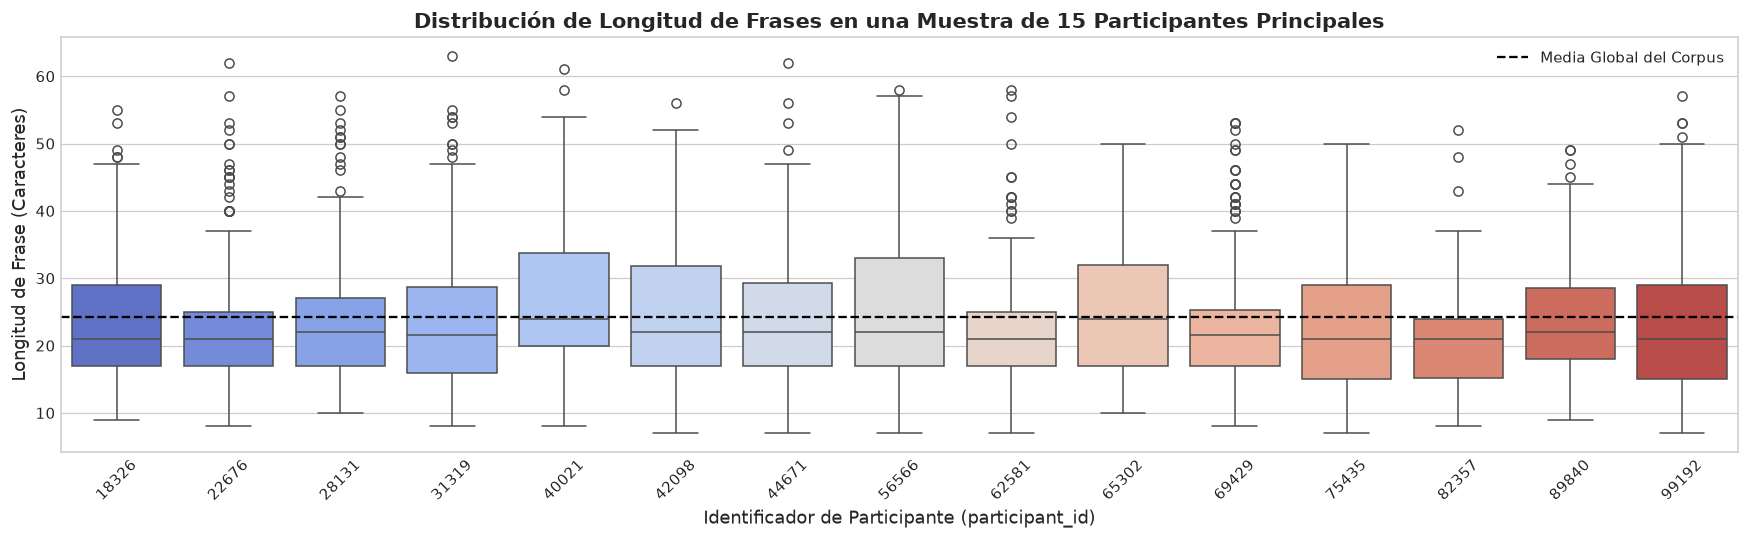

In [14]:
# Seleccionar una muestra representativa de 15 participantes
top_pids = part_counts.head(15).index.tolist()
sample_participants_df = df_meta[df_meta['participant_id'].isin(top_pids)]

plt.figure(figsize=(16, 5))
sns.boxplot(data=sample_participants_df, x='participant_id', y='char_length', palette='coolwarm')
plt.axhline(df_meta['char_length'].mean(), color='black', linestyle='--', label='Media Global del Corpus')
plt.title('Distribución de Longitud de Frases en una Muestra de 15 Participantes Principales', fontweight='bold')
plt.xlabel('Identificador de Participante (participant_id)')
plt.ylabel('Longitud de Frase (Caracteres)')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 9. Hallazgos y Conclusiones del Análisis Textual y de Metadatos

### 9.1 Hallazgos Clave
1. **Distribución de Longitud y Complejidad:**
   * La longitud media de las frases se sitúa en torno a **17 - 22 caracteres**, con un rango típico de **8 a 35 caracteres**. Existe una cola derecha (*skewness* positiva) compuesta por URLs y direcciones compuestas que superan los 40 caracteres.
   * La variabilidad en longitud exige el uso de mecanismos de alineamiento temporal elásticos (*Connectionist Temporal Classification - CTC* o *Attention-based Seq2Seq*) y estrategias de *padding* dinámico para minimizar el desperdicio computacional en lotes.

2. **Severo Desbalance del Vocabulario de 59 Caracteres:**
   * Las letras más comunes (`e, t, a, o, i, n, s`) y el espacio (`' '`) dominan más del **70% del volumen total de caracteres**.
   * Los dígitos numéricos (`0-9`) y símbolos de puntuación (`@, ., -, /, #, ~`) representan clases fuertemente minoritarias. Esto alerta sobre un alto riesgo de que los modelos aprendan a ignorar caracteres especiales a menos que se apliquen técnicas de ponderación de pérdida (*focal loss* o *class weights*).

3. **Patrones de Co-articulación en N-Gramas:**
   * Los bigramas dominantes (`th`, `he`, `in`, `er`, `an`, `re`, `on`) reflejan las transiciones más habituales de la lengua inglesa. La alta probabilidad de transición observada en la matriz de calor demuestra que el modelo de reconocimiento biomecánico debe capturar dependencias temporales locales para resolver la continuidad del movimiento entre dedos.

4. **Representatividad Muestral y Ausencia de Sesgo Extremo:**
   * La distribución de aportaciones entre los 147 participantes presenta un coeficiente de Gini moderado (menor a 0.35), lo que evidencia una recolección equilibrada sin que ningún participante domine excesivamente el conjunto de datos.
   * La longitud promedio de las frases es consistente entre participantes, lo que confirma que las diferencias en tiempo total de firma (analizadas en la dimensión temporal) se deberán a la velocidad intrínseca del firmante y no a una disparidad en la dificultad del texto asignado.

---
### 9.2 Implicaciones para las Siguientes Fases del Análisis:
* **Para el Análisis Temporal:** Utilizar la métrica `char_length` calculada aquí para relacionarla con el número de frames por secuencia en los archivos Parquet, calculando la velocidad real de deletreo (*frames por carácter*).
* **Para el Modelado y Análisis Cinemático:** Tomar en cuenta el desbalance de caracteres y los bigramas frecuentes para correlacionar las trayectorias espaciales de la mano dominante con las letras de mayor y menor dispersión articular.